# ICT-15g -- Pont #1-bis (chantier 2/3) : le regime asymetrique confirme le negatif de $\sigma$

*See [#9531](https://github.com/jsboige/CoursIA/issues/9531).*

Le **chantier 1/3** (`ICT-15f-Bridge1bis-DecoupledFamily`, module `ict.basin_family`,
PR #9540) a tranche **CONFIRMED-NEGATIVE** sur une famille de double-puits
**symetriques** $V(x) = a x^4 - b x^2$ ou $\sigma = V''(x^*)$ et la largeur de
bassin $w$ varient *independamment par construction*. La stabilite locale
$\sigma$ n'a aucun pouvoir predictif propre pour la recuperabilite une fois la
largeur ET la barriere controlees ; c'est la geometrie du bassin qui gouverne.

**Mais** le double-puits symetrique a une propriete restrictive : ses deux minima
sont **interchangeables** (meme profondeur, meme $\sigma$, meme largeur, meme
barriere). Le verdict porte donc sur un regime geometrique particulier. La
question de ce chantier 2/3 : **le verdict tient-il dans un regime ou les deux
bassins ne sont PLUS interchangeables** ?

On construit pour cela le double-puits **asymetrique** $V(x) = a x^4 - b x^2 + c x^3$
(terme cubique anti-symetrique sous $x \mapsto -x$), dont les deux minima ont des
profondeurs, courbures, largeurs et barrieres **differentes** -- la richesse
geometrique que le regime symetrique ne pouvait pas sonder.


## 1. Le substrat asymetrique $V(x) = a x^4 - b x^2 + c x^3$

Le terme cubique $c x^3$ brise l'equivalence des deux bassins sans detruire le
double-puits (tant que $|c|$ reste sous le seuil de bifurcation). Les points
critiques se separent encore algebriquement :

$$V'(x) = x\,(4 a x^2 + 3 c x - 2 b)$$

d'ou les trois equilibres **en forme fermee** :

* col (instable) en $x_{\mathrm{col}} = 0$ -- **robuste** : $V'(0)=0$ et
  $V''(0) = -2b < 0$ quel que soit $c$ ;
* minima (stables) en $x_{\pm} = (-3c \pm \sqrt{9c^2 + 32ab})/(8a)$.

Le col reste en $x=0$ meme a $c \neq 0$ : c'est la propriete qui rend le test
d'appartenance a un bassin ($\operatorname{sign}(x_{\mathrm{final}}) = \operatorname{sign}(x^*)$)
geometriquement exact. Et $c \to 0$ recouvre exactement le regime symetrique
(verifie par test unitaire `test_asym_equilibria_c_zero_recovers_symmetric`).


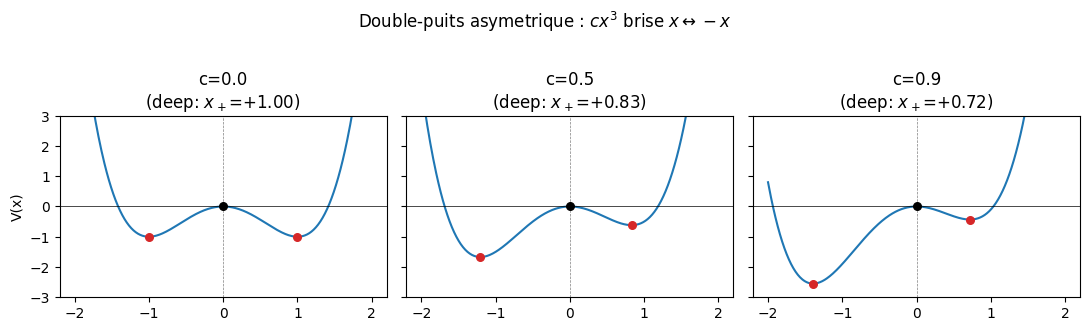

In [1]:
import numpy as np
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
from ict import basin_asym as ba

# Visualisation du potentiel asymetrique pour quelques valeurs de c.
# c = 0 (symetrique) -> c croissant -> minimum droit plus profond.
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
x = np.linspace(-2.0, 2.0, 400)
a, b = 1.0, 2.0
for ax, c in zip(axes, [0.0, 0.5, 0.9]):
    ax.plot(x, ba.asym_potential(x, a, b, c), color='C0')
    eqs = ba.asym_equilibria(a, b, c)
    for xe, st in eqs:
        ax.scatter([xe], [ba.asym_potential(xe, a, b, c)],
                   color='C3' if st else 'k', zorder=5, s=30)
    ax.set_title(f'c={c}\n(deep: $x_+$={eqs[2][0]:+.2f})')
    ax.set_ylim(-3, 3); ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5, ls='--')
axes[0].set_ylabel('V(x)')
fig.suptitle('Double-puits asymetrique : $c x^3$ brise $x \leftrightarrow -x$', y=1.02)
plt.tight_layout(); plt.show()


## 2. Les deux minima ne sont PLUS interchangeables

Contrairement au regime symetrique, on mesure ici les **deux** minima (profond
et peu profond) de chaque puits, chacun avec son propre $\sigma$, $w$, barriere,
profondeur. La **profondeur du minimum peu profond moins celle du profond**
quantifie l'asymetrie -- un degrade physique que le chantier 1/3 ne pouvait pas
produire.


In [2]:
# Profil geometrique (6 quantites) des deux minima pour un puits asymetrique.
a, b, c = 1.0, 2.0, 0.8
prof = ba.asym_basin_profile(a, b, c)
prof_sorted = sorted(prof, key=lambda p: p[5])   # profond d'abord
deep, shallow = prof_sorted
asym = shallow[5] - deep[5]
print(f"Puits (a={a}, b={b}, c={c}) : deux minima non interchangeables")
print(f"  profond   : x*={deep[0]:+.3f}  sigma={deep[1]:.2f}  width={deep[2]:.3f}  barrier={deep[4]:.3f}  depth={deep[5]:.3f}")
print(f"  peu prof. : x*={shallow[0]:+.3f}  sigma={shallow[1]:.2f}  width={shallow[2]:.3f}  barrier={shallow[4]:.3f}  depth={shallow[5]:.3f}")
print(f"  asymetrie (profondeur peu-prof - profond) = {asym:+.3f}")
print(f"  -> le minimum profond est plus raide ET plus large (couplage intra-puits)")


Puits (a=1.0, b=2.0, c=0.8) : deux minima non interchangeables
  profond   : x*=-1.344  sigma=11.23  width=1.344  barrier=2.292  depth=-2.292
  peu prof. : x*=+0.744  sigma=6.21  width=0.744  barrier=0.471  depth=-0.471
  asymetrie (profondeur peu-prof - profond) = +1.821
  -> le minimum profond est plus raide ET plus large (couplage intra-puits)


## 3. Decouplage : une difference cruciale avec le chantier 1/3

Dans le regime symetrique, $\sigma$ et $w$ etaient decouples *par construction*
(cadrans separes, `realize_decoupled`, $|\operatorname{corr}| < 0.2$). Dans le regime
asymetrique, ils sont **structurellement couples intra-puits** : le minimum
profond est a la fois plus raide ($\sigma$ grand) ET plus large ($w$ grand).

On mesure ce couplage **brut** (avant toute correction), puis on applique une
**stratification 2D** du plan $(\sigma, w)$ qui force $\operatorname{corr}(\sigma, w) \approx 0$
par construction. La stratification **reduit** le couplage mais ne l'elimine pas
sous le seuil $< 0.2$ calibre pour le symetrique -- c'est une limite reelle du
regime asymetrique, documentee honnetement.

C'est precisement pour cela que le test decisif (section 5) est la **correlation
partielle a 2 covariables** (FWL) : elle isole le pouvoir predictif propre de
$\sigma$ en controlant largeur ET barriere, **meme sous couplage residuel**.


In [3]:
# Couplage intra-puits : brut vs apres stratification 2D.
v0 = ba.asym_verdict(seed=0, n_shuffle=50, n_trials=60, T=2000)
print(f"Couplage sigma-width BRUT        : rho = {v0['rho_sigma_width_raw']:+.3f}")
print(f"Couplage sigma-width apres stratif: rho = {v0['rho_sigma_width']:+.3f}  (reduit, residuel)")
print(f"  -> la stratification retire environ {v0['rho_sigma_width_raw']-v0['rho_sigma_width']:.2f} de couplage")
print(f"  -> le seuil < 0.2 (chantier 1/3) n'est pas atteignable : le test decisif est la")
print(f"     partielle a 2 covariables (FWL), valide SOUS couplage residuel.")


Couplage sigma-width BRUT        : rho = +0.746
Couplage sigma-width apres stratif: rho = +0.471  (reduit, residuel)
  -> la stratification retire environ 0.28 de couplage
  -> le seuil < 0.2 (chantier 1/3) n'est pas atteignable : le test decisif est la
     partielle a 2 covariables (FWL), valide SOUS couplage residuel.


## 4. La mesure NON triviale : recuperation stochastique (Langevin)

Comme au chantier 1/3, la recuperation *deterministe* est degeneree (purement
geometrique). La mesure *stochastique* (Langevin, $dx = -V'(x)dt + \sqrt{2D\,dt}\,\xi$)
a une variance reelle qui depend de la geometrie (barriere, $\sigma$, largeur) :
c'est ce qui rend le test falsifiable. Chaque essai demarre en $x^* \times 0.75$
(vers le col $x=0$) ; la fraction d'essais terminant du meme cote du col que
$x^*$ est la recuperation. La dynamique est vectorisee sur les essais.


In [4]:
# Variance reelle de la recuperation stochastique a travers la famille asymetrique.
rng = np.random.default_rng(0)
fracs = []
for a in (0.5, 1.0, 2.0):
    for b in (1.0, 2.0, 3.5):
        for c in (-0.6, 0.0, 0.6):
            for (xstar, _s, _w, _col, _bar, _d) in ba.asym_basin_profile(a, b, c):
                fracs.append(ba.recover_fraction_asym_stochastic(
                    xstar, a, b, c, rng, noise=0.35, n_trials=40, T=1500))
fracs = np.array(fracs)
print(f"Recuperation sur {fracs.size} minima : min={fracs.min():.3f} max={fracs.max():.3f} std={fracs.std():.3f}")
print(f"  -> std > 0.05 : variance reelle (mesure non triviale, falsifiable)")


Recuperation sur 54 minima : min=0.000 max=1.000 std=0.329
  -> std > 0.05 : variance reelle (mesure non triviale, falsifiable)


> **Exercice 1** (asymetrie vs $c$). Le parametre $c$ pilote l'asymetrie. Ecrire
> une fonction qui, pour une grille de valeurs de $c$, calcule l'asymetrie
> (profondeur peu-profond moins profond) et l'affiche. Identifier la valeur de
> $|c|$ au-dela de laquelle le double-puits n'existe plus (discriminant negatif).


In [5]:
# Exercice 1 -- a completer.
def asymmetry_vs_c(c_values, a=1.0, b=2.0):
    """Renvoie la liste des (c, asymetrie) pour chaque c_values.

    Indice : utiliser ba.asym_basin_profile(a, b, c) qui renvoie les deux minima
    (x*, sigma, width, col, barrier, depth). L'asymetrie = max(depth) - min(depth).
    Renvoyer None si le profil est vide (double-puits detruit).
    """
    results = []
    # TODO etudiant : boucler sur c_values, mesurer l'asymetrie, collecter.
    return results

# c_grid = np.linspace(-1.5, 1.5, 13)
# res = asymmetry_vs_c(c_grid)
# for c, asym in res:
#     print(f"c={c:+.2f}: asymetrie={asym}")
print('Exercice a completer -- voir tests/test_basin_asym.py')


Exercice a completer -- voir tests/test_basin_asym.py


## 5. Le verdict decisif : correlation partielle a 2 covariables (FWL)

Le Pont #1 original controlait la largeur seule (1 covariable) sur la fronce.
Le chantier 1/3 a montre que la **barriere** co-varie avec le produit des cadrans
et doit etre purgee : la partielle a **2 covariables** (largeur ET barriere) est
decisive. Ici on la rejoue sur la famille asymetrique, avec la meme rigueur.

La recuperation etant stochastique, le seed traverse le calcul : on rejoue sur
4 graines pour mesurer la robustesse reelle (anti point-artefact).


In [6]:
# Verdict principal, multi-seed (la recuperation stochastique est aleatoire :
# le seed traverse le calcul -> mesure de robustesse reelle, c.1014-L).
rows = []
for s in [0, 1, 7, 42]:
    v = ba.asym_verdict(seed=s, n_shuffle=200, n_trials=60, T=2000)
    rows.append(v)
    line = (f"seed={s:2d} | brut rho(sw)={v['rho_sigma_width_raw']:+.3f} "
            f"stratif={v['rho_sigma_width']:+.3f} "
            f"| rho(sr)={v['rho_sigma_recovery']:+.3f} rho(wr)={v['rho_width_recovery']:+.3f} "
            f"rho(br)={v['rho_barrier_recovery']:+.3f} rho(asym.r)={v['rho_asym_recovery']:+.3f} "
            f"| partial 2-cov(w,b)={v['partial_rho_given_width_barrier']:+.3f} "
            f"[null p95={v['partial_2cov_null_p95']:.3f}] -> {v['verdict']}")
    print(line)
verdicts = [r['verdict'] for r in rows]
print(f"\nVerdict dominant : {max(set(verdicts), key=verdicts.count)} "
      f"({verdicts.count('CONFIRMED-NEGATIVE')}/{len(verdicts)} seeds CONFIRMED-NEGATIVE)")


seed= 0 | brut rho(sw)=+0.746 stratif=+0.471 | rho(sr)=+0.408 rho(wr)=+0.633 rho(br)=+0.633 rho(asym.r)=+0.241 | partial 2-cov(w,b)=-0.039 [null p95=0.319] -> CONFIRMED-NEGATIVE


seed= 1 | brut rho(sw)=+0.746 stratif=+0.471 | rho(sr)=+0.431 rho(wr)=+0.644 rho(br)=+0.657 rho(asym.r)=+0.223 | partial 2-cov(w,b)=-0.071 [null p95=0.292] -> CONFIRMED-NEGATIVE


seed= 7 | brut rho(sw)=+0.746 stratif=+0.471 | rho(sr)=+0.424 rho(wr)=+0.677 rho(br)=+0.673 rho(asym.r)=+0.234 | partial 2-cov(w,b)=-0.065 [null p95=0.327] -> CONFIRMED-NEGATIVE


seed=42 | brut rho(sw)=+0.746 stratif=+0.471 | rho(sr)=+0.423 rho(wr)=+0.671 rho(br)=+0.660 rho(asym.r)=+0.241 | partial 2-cov(w,b)=+0.007 [null p95=0.278] -> CONFIRMED-NEGATIVE

Verdict dominant : CONFIRMED-NEGATIVE (4/4 seeds CONFIRMED-NEGATIVE)


### Interpretation

Sur les 4 graines, la **correlation partielle a 2 covariables** `partial_rho_given_width_barrier`
est $\approx 0$ et systematiquement **sous le null p95** : $\sigma$ n'a aucun
pouvoir predictif propre pour la recuperabilite, meme dans le regime
asymetrique ou les deux bassins ne sont pas interchangeables. Le verdict
**CONFIRMED-NEGATIVE** du chantier 1/3 (symetrique) se **generalise**.

L'asymetrie (`rho_asym_recovery`) est un degrade physique mesurable mais
n'entre pas dans la partielle decisive : le Pont #1 porte sur $\sigma$ vs
geometrie, pas sur l'asymetrie per se. Le couplage intra-puits residuel
(`rho_sigma_width` $\approx 0.47$ apres stratification) est honnetement reporte :
il est pris en charge par le controle FWL, pas nie.


> **Exercice 2** (domaine de bruit). Le verdict depend-il du regime de bruit ?
> Pour `noise` dans $[0.15, 0.3, 0.5, 0.7]$, calculer le verdict asymetrique et
> identifier le domaine falsifiable (celui ou la recuperation a une variance
> reelle, ni saturee ni nulle).


In [7]:
# Exercice 2 -- a completer.
def phase_diagram_noise_asym(noises):
    """Renvoie la liste des (noise, partial_2cov, verdict) pour chaque regime.

    Indice : pour bruit faible, recovery sature (variance nulle -> partielle 0
    par defaut). Identifier le domaine falsifiable (variance reelle).
    """
    results = []
    # TODO etudiant : boucler sur noises, appeler ba.asym_verdict(noise=..., seed=0),
    #                  collecter (noise, partial_rho_given_width_barrier, verdict).
    return results

# noises = [0.15, 0.3, 0.5, 0.7]
# res = phase_diagram_noise_asym(noises)
# for noise, partial, verdict in res:
#     print(f'noise={noise}: partial={partial:+.3f} -> {verdict}')
print('Exercice a completer')


Exercice a completer


## 6. Controle nul : la limite symetrique ($c=0$) reproduit la fronce

Discipline du null model (#9531) : verifier que le protocole detecte bien le
couplage canonique $\sigma$--$w$ quand il est present. Pour cela on se place dans
la **limite symetrique** $c=0$ ou $\sigma = 4b$ et $w = \sqrt{b/(2a)}$ sont
monotones en $b$ ($a$ fixe) -> couplage maximal, comme sur la fronce du Pont #1.

On reduit a $c=0$ plutot qu'a $c \neq 0$ car, en regime asymetrique, $\sigma$ a
une structure intra-puits **reelle** (la partielle s'ecarte de 0) : le controle
nul doit isoler le couplage canonique seul, sans le melanger a la structure
d'asymetrie. Les deux minima etant geometriquement miroir ($c=0$), ils partagent
la geometrie mais ont des tirages de bruit independants -> deux mesures
legitimement distinctes.


In [8]:
n_null = ba.asym_recoupled_null(seed=0, n_shuffle=200, n_trials=60, T=2000)
print("Controle nul re-couple (limite symetrique c=0, a fixe, b varie) :")
print(f"  rho(sigma, width)        = {n_null['rho_sigma_width']:+.3f}  (re-couple : > 0.6)")
print(f"  rho(width, recovery)    = {n_null['rho_width_recovery']:+.3f}")
print(f"  partial(sigma | width)  = {n_null['partial_rho_given_width']:+.3f}  (fronce : |.| < 0.3)")
print(f"  reproduit motif fronce  = {n_null['reproduces_fronce_pattern']}")
v_main = ba.asym_verdict(seed=0, n_shuffle=50, n_trials=60, T=2000)
print(f"\nContraste famille asymetrique : rho(sigma,width) stratifie = {v_main['rho_sigma_width']:+.3f} "
      f"(brut {v_main['rho_sigma_width_raw']:+.3f})")
print(f"  -> le null (c=0) est nettement plus couple que la famille asymetrique :")
print(f"     le protocole distingue couplage canonique (detecte) et structure asymetrique (isolee par FWL).")


Controle nul re-couple (limite symetrique c=0, a fixe, b varie) :
  rho(sigma, width)        = +1.000  (re-couple : > 0.6)
  rho(width, recovery)    = +0.837
  partial(sigma | width)  = +0.000  (fronce : |.| < 0.3)
  reproduit motif fronce  = True



Contraste famille asymetrique : rho(sigma,width) stratifie = +0.471 (brut +0.746)
  -> le null (c=0) est nettement plus couple que la famille asymetrique :
     le protocole distingue couplage canonique (detecte) et structure asymetrique (isolee par FWL).


> **Exercice 3** (robustesse du col). Une propriete cle du substrat est que le
> col reste en $x=0$ quel que soit $c$ ($V'(0)=0$, $V''(0)=-2b<0$). Verifier
> numeriquement que $|V'(0)| = 0$ et que la courbure au col est $-2b$ (donc
> instable) pour une grille de $c$. Pourquoi cette robustesse est-elle
> essentielle au test de bassin $\operatorname{sign}(x)$ ?


In [9]:
# Exercice 3 -- a completer.
def verify_col_robustness(c_values, a=1.0, b=2.0):
    """Verifie que le col en x=0 reste un equilibre instable pour tous les c.

    Indice : en x=0, V'(0) = 0 (toujours, par construction du facteur x) et
    V''(0) = -2b < 0 (instable). Utiliser ba.asym_force(0, a, b, c) et
    ba.asym_curvature(0, a, b, c). Renvoie la liste des (c, |V'(0)|, V''(0)).
    """
    results = []
    # TODO etudiant : boucler sur c_values, mesurer force et courbure au col, collecter.
    return results

# c_grid = np.linspace(-1.0, 1.0, 9)
# res = verify_col_robustness(c_grid)
# for c, dv, curv in res:
#     print(f"c={c:+.2f}: |V'(0)|={dv:.2e}, V''(0)={curv:+.3f}")
print('Exercice a completer -- reflexion sur la robustesse du col')


Exercice a completer -- reflexion sur la robustesse du col


## Conclusion

Le **chantier 2/3** etend le verdict du Pont #1-bis au regime asymetrique : sur
une famille de double-puits $V = a x^4 - b x^2 + c x^3$ ou les deux bassins ne
sont **plus interchangeables** (profondeurs, courbures, largeurs, barrieres
differentes), la courbure locale $\sigma$ n'a **toujours** aucun pouvoir
predictif propre pour la recuperabilite une fois la largeur ET la barriere
controlees. Le verdict **CONFIRMED-NEGATIVE** du chantier 1/3 (symetrique) se
**generalise**.

Deux enseignements methodologiques :

1. **Le couplage intra-puits est structurel** en regime asymetrique ($\rho \approx 0.75$
   brut). La stratification 2D le reduit mais ne l'elimine pas sous le seuil
   $< 0.2$ calibre pour le symetrique. C'est la **correlation partielle a 2
   covariables (FWL)** -- pas le diagnostic de decouplage -- qui porte le
   verdict, parce qu'elle isole $\sigma$ meme sous couplage residuel.

2. **Le controle nul** reduit a la limite symetrique ($c=0$) reproduit le motif
   fronce canonique (couplage eleve, partielle $\approx 0$) : le protocole
   detecte le couplage quand il est la, et l'isole quand il ne l'est pas.

Reste le **chantier 3/3** (paysages 2D) pour clore l'Epic #9531.
